# Email Normalizer Exercise

In this exercise, you will:
- Download two sets of emails
  - [Set 1 - 10 emails](https://drive.google.com/file/d/1t1g5jTW5rUJ9iDkJjRpXrNSuIIO2_ISA/view?usp=drive_link)
  - [Set 2 - 60 emails](https://drive.google.com/file/d/1gAzT8UduCuIl5gk7V6CcMAMTKbRQKYSb/view?usp=drive_link)
- Write an email-normalizing agent

### Scenario:
**Problem**: We don't know what flows confuse our users the most.  
Based on this series of customer-service emails- what are our users emailing us about?

---

- Produce a list of normalized questions our users are asking.  

- If two users are asking the same question in a different way, store it as a "vote" for the same question.  

- At the end, produce a list of the questions we receive, and how many of each.  

- Make sure the list is much smaller than the number of emails that are input.  

Psudeocode:
 - Present the agent with 1 email at a time
 - Ask the agent to "normalize" questions in the email by calling the "normalized_question" tool - the agent might call it multiple times per email
 - Present the agent with a list of questions that have been seen before, every time a new email is presented

In [ ]:
%%capture --no-stderr
%pip install --upgrade --force-reinstall langgraph
%pip install --quiet -U langchain_openai langchain_core
%pip install requests

In [ ]:
from langchain_openai import ChatOpenAI
from google.colab import userdata
import json

questions_seen_so_far = {}

def normalize_question(normalized_question: str) -> str:
    """Save a new normalized question, or a vote for an already-seen normalized question

    Args:
        normalized_question: The normalized question to save

    Returns:
        str: all questions we have seen so far
    """
    if normalized_question in questions_seen_so_far:
        questions_seen_so_far[normalized_question] += 1
    else:
        questions_seen_so_far[normalized_question] = 1
    print(questions_seen_so_far)
    return json.dumps(list(questions_seen_so_far.keys()))

tools = [normalize_question]

llm = ChatOpenAI(
    api_key=userdata.get('OPENAI_API_KEY'),
    model="gpt-5-mini-2025-08-07",
    temperature=0,
    max_tokens=8000)

llm_with_tools = llm.bind_tools(tools)


def save_helpdesk_article(article:str, article_title: str) -> str:
  """Save a helpdesk article to a file

    Args:
      article: The text of the article to save
      article_title: the title of the article
  """
  with open("./" + article_title + ".txt", "w") as f:
    f.write(article)
  return "success"

helpdesk_with_tools = llm.bind_tools([save_helpdesk_article])

In [ ]:
from langgraph.graph import MessagesState
from langchain_core.messages import AIMessage, HumanMessage, SystemMessage, ToolMessage


# System message

# Node
def assistant(state: MessagesState):
   if len(questions_seen_so_far.keys()) > 0:
        system_prompt = "Your role is to normalize the questions our customers are asking us over email. Use the normalize_question tool to extract a normalized form of the questions being asked in this email. Please normalize them as much as possible, if any questions can be grouped, do so. Reduce duplicates, the results of this will be used to write helpdesk articles that work for many use cases."
        system_prompt += "\nHere are the questions you have seen so far:"
        for question in questions_seen_so_far.keys():
            system_prompt += "\n- " + question
   else:
        system_prompt = "Your role is to normalize the questions our customers are asking us over email. Use the normalize_question tool to extract a normalized form of the questions being asked in this email. Please normalize them as much as possible, if any questions can be grouped, do so. Reduce duplicates, the results of this will be used to write helpdesk articles that work for many use cases."
   sys_msg = SystemMessage(content=system_prompt)

   return {"messages": [llm_with_tools.invoke([sys_msg] + state["messages"])]}

def helpdesk_writer(state: MessagesState):
   if len(questions_seen_so_far.keys()) > 0:
        system_prompt = "You are an expert Help Desk article author. You'll be given a question when asked by a user, and your goal will be to write a new Help Desk article to help all users who might have a similar question."
   sys_msg = SystemMessage(content=system_prompt)

   return {"messages": [helpdesk_with_tools.invoke([sys_msg] + state["messages"])]}

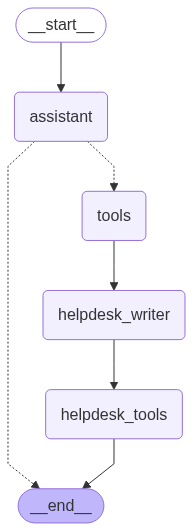

In [ ]:
from langgraph.graph import START, StateGraph, END
from langgraph.prebuilt import tools_condition, ToolNode
from IPython.display import Image, display

# Graph
builder = StateGraph(MessagesState)

# Define nodes: these do the work
builder.add_node("assistant", assistant)
builder.add_node("tools", ToolNode(tools))
builder.add_node("helpdesk_writer", helpdesk_writer)
builder.add_node("helpdesk_tools", ToolNode([save_helpdesk_article]))

# Define edges: these determine how the control flow moves
builder.add_edge(START, "assistant")
builder.add_conditional_edges(
    "assistant",
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is a not a tool call -> tools_condition routes to END
    tools_condition,
)
builder.add_edge("tools", "helpdesk_writer")
builder.add_edge("helpdesk_writer", "helpdesk_tools")
builder.add_edge("helpdesk_tools", END)

# Compile
react_graph = builder.compile(debug=True)

# Show
display(Image(react_graph.get_graph(xray=True).draw_mermaid_png()))

In [ ]:
import csv

# Open the CSV file
with open('quickbooks_emails.csv', 'r', newline='') as csvfile:
    # Create a csv.reader object
    csv_reader = csv.reader(csvfile)

    # Optionally, skip the header row if present
    header = next(csv_reader)
    print(f"Header: {header}")

    # Iterate over each row in the CSV file
    for row in csv_reader:
        print(row)
        messages = [HumanMessage(content=row[1])]
        messages = react_graph.invoke({"messages": messages})
        for m in messages['messages']:
            m.pretty_print()

Header: ['Subject', 'Body']
['Credit card balance won’t reconcile', "Hey,\nNot sure what I’m doing wrong, but my credit card balance in QuickBooks doesn't match my bank statement—even though I double-checked and all the transactions seem to be there. Is there something else that could be throwing it off?\n\n—Marco"]
[values] {'messages': [HumanMessage(content="Hey,\nNot sure what I’m doing wrong, but my credit card balance in QuickBooks doesn't match my bank statement—even though I double-checked and all the transactions seem to be there. Is there something else that could be throwing it off?\n\n—Marco", additional_kwargs={}, response_metadata={}, id='2130cb39-8dca-4f4b-ade9-b72146c15a25')]}
[updates] {'assistant': {'messages': [AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'call_SZpswl3VrMg0WfCh8F4kErOM', 'function': {'arguments': '{"normalized_question":"Why does the credit card account balance in QuickBooks not match my bank/credit card statement even though all tra

KeyboardInterrupt: 

In [ ]:
import pprint

pprint.pp(questions_seen_so_far)


{'Why doesn’t my QuickBooks credit card account balance match my bank statement even though all transactions appear to be entered?': 1,
 'How do I record customer prepayments (upfront payments) in QuickBooks so they aren’t recognized as income until the work is completed, and how do I apply that prepayment to the customer’s invoice once the work is done?': 2,
 "How do I set up a kit (assembled product) in QuickBooks so that building a kit reduces each component's inventory, and how can I determine how many kits I can assemble from current inventory?": 1,
 'How should I record owner draws in QuickBooks when I use QuickBooks Payroll but the owner doesn’t take a salary, and can monthly owner draws be automated or do they need to be entered manually?': 1,
 'When converting from QuickBooks Desktop to QuickBooks Online, what data will be migrated (payroll history, inventory details, vendors, customers, transactions, etc.), what data will not migrate or may be limited, how will reports be aff

Your prompt to the agent should look (something like) this on the first email:
```
Your role is to normalize the emails our customers are asking us. Use the normalize_question tool to extract a normalized form of the questions being asked in this email.
```

Your prompt should look something like this on the second email:
```
Your role is to normalize the emails our customers are asking us. Use the normalize_question tool to extract a normalized form of the questions being asked in this email.
Here are the questions you have seen so far:
- How do I pay myself in Quickbooks?
- How do I set up a recurring invoice in Quickbooks?
```

On the third:
```
Your role is to normalize the emails our customers are asking us. Use the normalize_question tool to extract a normalized form of the questions being asked in this email.
Here are the questions you have seen so far:
- How do I pay myself in Quickbooks?
- How do I set up a recurring invoice in Quickbooks?
- How do I clear an invoice I have written off in Quickbooks?
```